# Loan Default Prediction using Artificial Neural Networks

## Objective:

The objective of this project is to build a binary classification model using TensorFlow/Keras that predicts whether a borrower is likely to fully repay a loan or default.

The project includes:

- Exploratory Data Analysis (EDA)
- Missing value treatment
- Feature engineering
- Categorical encoding
- Feature scaling
- ANN model development
- Model evaluation

## Business Problem

Financial institutions face significant losses when borrowers fail to repay loans.

Traditional loan approval processes often rely on manual assessment and predefined credit rules, which may not capture complex patterns in customer behavior.

By leveraging historical lending data, an Artificial Neural Network can help identify high-risk applicants and support more informed lending decisions.

-----
Here is the information on this particular data set:

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>LoanStatNew</th>
      <th>Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>loan_amnt</td>
      <td>The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.</td>
    </tr>
    <tr>
      <th>1</th>
      <td>term</td>
      <td>The number of payments on the loan. Values are in months and can be either 36 or 60.</td>
    </tr>
    <tr>
      <th>2</th>
      <td>int_rate</td>
      <td>Interest Rate on the loan</td>
    </tr>
    <tr>
      <th>3</th>
      <td>installment</td>
      <td>The monthly payment owed by the borrower if the loan originates.</td>
    </tr>
    <tr>
      <th>4</th>
      <td>grade</td>
      <td>LC assigned loan grade</td>
    </tr>
    <tr>
      <th>5</th>
      <td>sub_grade</td>
      <td>LC assigned loan subgrade</td>
    </tr>
    <tr>
      <th>6</th>
      <td>emp_title</td>
      <td>The job title supplied by the Borrower when applying for the loan.*</td>
    </tr>
    <tr>
      <th>7</th>
      <td>emp_length</td>
      <td>Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years.</td>
    </tr>
    <tr>
      <th>8</th>
      <td>home_ownership</td>
      <td>The home ownership status provided by the borrower during registration or obtained from the credit report. Our values are: RENT, OWN, MORTGAGE, OTHER</td>
    </tr>
    <tr>
      <th>9</th>
      <td>annual_inc</td>
      <td>The self-reported annual income provided by the borrower during registration.</td>
    </tr>
    <tr>
      <th>10</th>
      <td>verification_status</td>
      <td>Indicates if income was verified by LC, not verified, or if the income source was verified</td>
    </tr>
    <tr>
      <th>11</th>
      <td>issue_d</td>
      <td>The month which the loan was funded</td>
    </tr>
    <tr>
      <th>12</th>
      <td>loan_status</td>
      <td>Current status of the loan</td>
    </tr>
    <tr>
      <th>13</th>
      <td>purpose</td>
      <td>A category provided by the borrower for the loan request.</td>
    </tr>
    <tr>
      <th>14</th>
      <td>title</td>
      <td>The loan title provided by the borrower</td>
    </tr>
    <tr>
      <th>15</th>
      <td>zip_code</td>
      <td>The first 3 numbers of the zip code provided by the borrower in the loan application.</td>
    </tr>
    <tr>
      <th>16</th>
      <td>addr_state</td>
      <td>The state provided by the borrower in the loan application</td>
    </tr>
    <tr>
      <th>17</th>
      <td>dti</td>
      <td>A ratio calculated using the borrower’s total monthly debt payments on the total debt obligations, excluding mortgage and the requested LC loan, divided by the borrower’s self-reported monthly income.</td>
    </tr>
    <tr>
      <th>18</th>
      <td>earliest_cr_line</td>
      <td>The month the borrower's earliest reported credit line was opened</td>
    </tr>
    <tr>
      <th>19</th>
      <td>open_acc</td>
      <td>The number of open credit lines in the borrower's credit file.</td>
    </tr>
    <tr>
      <th>20</th>
      <td>pub_rec</td>
      <td>Number of derogatory public records</td>
    </tr>
    <tr>
      <th>21</th>
      <td>revol_bal</td>
      <td>Total credit revolving balance</td>
    </tr>
    <tr>
      <th>22</th>
      <td>revol_util</td>
      <td>Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.</td>
    </tr>
    <tr>
      <th>23</th>
      <td>total_acc</td>
      <td>The total number of credit lines currently in the borrower's credit file</td>
    </tr>
    <tr>
      <th>24</th>
      <td>initial_list_status</td>
      <td>The initial listing status of the loan. Possible values are – W, F</td>
    </tr>
    <tr>
      <th>25</th>
      <td>application_type</td>
      <td>Indicates whether the loan is an individual application or a joint application with two co-borrowers</td>
    </tr>
    <tr>
      <th>26</th>
      <td>mort_acc</td>
      <td>Number of mortgage accounts.</td>
    </tr>
    <tr>
      <th>27</th>
      <td>pub_rec_bankruptcies</td>
      <td>Number of public record bankruptcies</td>
    </tr>
  </tbody>
</table>

----

In [5]:
import pandas as pd

In [6]:
data_info = pd.read_csv('../DATA/lending_club_info.csv',index_col='LoanStatNew')

In [7]:
print(data_info.loc['revol_util']['Description'])

Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.


In [8]:
def feat_info(col_name):
    print(data_info.loc[col_name]['Description'])

In [9]:
feat_info('mort_acc')

Number of mortgage accounts.


In [10]:
feat_info('open_acc')

The number of open credit lines in the borrower's credit file.


## Loading the data and other imports

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# might be needed depending on your version of Jupyter
%matplotlib inline

In [8]:
df = pd.read_csv('../DATA/lending_club_loan_two.csv')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

# Exploratory Data Analysis (EDA)

In this section, we analyze the loan dataset to understand the distribution of features, identify patterns associated with loan repayment behavior, and gain insights that will guide feature engineering and model development.

-----
------

## Section 1: Exploratory Data Analysis

The objective of this analysis is to explore feature distributions, investigate relationships between variables, and understand factors that may influence loan repayment outcomes.


----

### Distribution of Target Variable (loan_status)

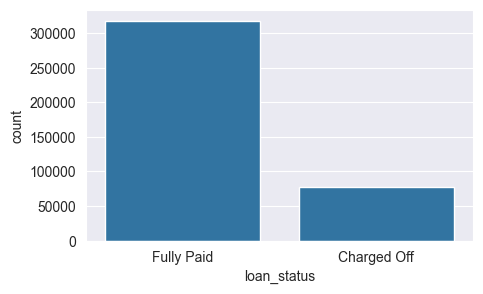

In [10]:

fig=plt.figure(figsize=(5,3))
sns.set_style('darkgrid')
sns.countplot(x='loan_status',data=df)
plt.show()

### Loan Amount Distribution

This visualization shows the distribution of loan amounts issued by LendingClub borrowers.

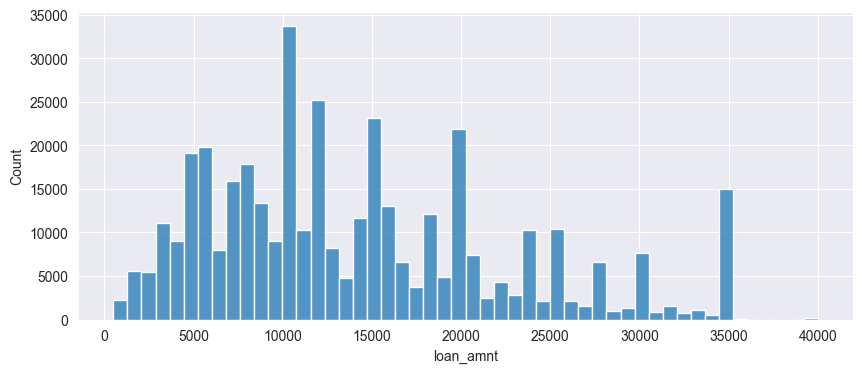

In [11]:
fig=plt.figure(figsize=(10,4))
sns.histplot(df['loan_amnt'],bins=50)
plt.show()

### Correlation Analysis of Numerical Features

To identify relationships between numerical variables, a correlation matrix is computed.

In [12]:
df.corr(numeric_only=True)

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
loan_amnt,1.000000,0.168921,0.953929,0.336887,0.016636,0.198556,-0.077779,0.328320,0.099911,0.223886,0.222315,-0.106539
int_rate,0.168921,1.000000,0.162758,-0.056771,0.079038,0.011649,0.060986,-0.011280,0.293659,-0.036404,-0.082583,0.057450
installment,0.953929,0.162758,1.000000,0.330381,0.015786,0.188973,-0.067892,0.316455,0.123915,0.202430,0.193694,-0.098628
annual_inc,0.336887,-0.056771,0.330381,1.000000,-0.081685,0.136150,-0.013720,0.299773,0.027871,0.193023,0.236320,-0.050162
dti,0.016636,0.079038,0.015786,-0.081685,1.000000,0.136181,-0.017639,0.063571,0.088375,0.102128,-0.025439,-0.014558
open_acc,0.198556,0.011649,0.188973,0.136150,0.136181,1.000000,-0.018392,0.221192,-0.131420,0.680728,0.109205,-0.027732
pub_rec,-0.077779,0.060986,-0.067892,-0.013720,-0.017639,-0.018392,1.000000,-0.101664,-0.075910,0.019723,0.011552,0.699408
revol_bal,0.328320,-0.011280,0.316455,0.299773,0.063571,0.221192,-0.101664,1.000000,0.226346,0.191616,0.194925,-0.124532
revol_util,0.099911,0.293659,0.123915,0.027871,0.088375,-0.131420,-0.075910,0.226346,1.000000,-0.104273,0.007514,-0.086751
total_acc,0.223886,-0.036404,0.202430,0.193023,0.102128,0.680728,0.019723,0.191616,-0.104273,1.000000,0.381072,0.042035


### Correlation Heatmap

The heatmap provides a visual representation of feature correlations and helps identify highly related variables.

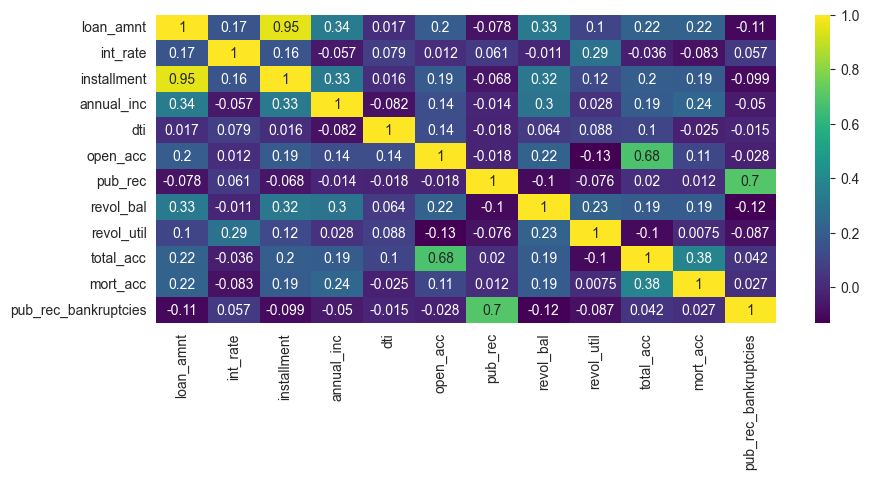

In [13]:

fig=plt.figure(figsize=(10,4))
sns.heatmap(df.corr(numeric_only=True),cmap='viridis',annot=True)
plt.show()

### Investigating Highly Correlated Features

The correlation analysis revealed a strong relationship between loan amount and installment amount. This relationship is explored further to determine whether both features provide redundant information.

In [14]:
feat_info('installment')

The monthly payment owed by the borrower if the loan originates.


In [15]:
feat_info('loan_amnt')

The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.


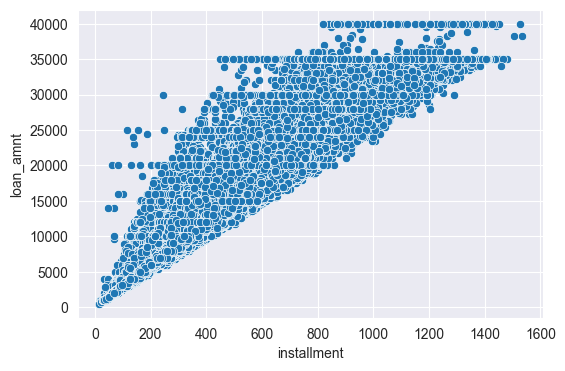

In [16]:
fig=plt.figure(figsize=(6,4))
sns.scatterplot(x='installment',y='loan_amnt',data=df,edgecolor='white')
plt.show()

### Loan Amount by Repayment Status

A boxplot is used to compare loan amounts across different repayment outcomes.

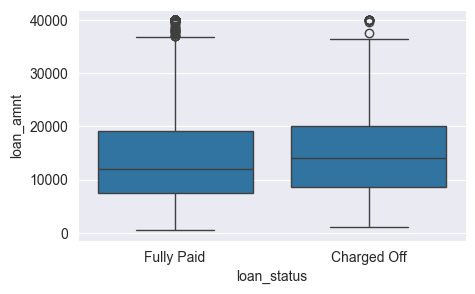

In [17]:
fig=plt.figure(figsize=(5,3))
sns.boxplot(x='loan_status',y='loan_amnt',data=df)
plt.show()

### Summary Statistics by Loan Status

Descriptive statistics are calculated to better understand differences between fully paid and charged-off loans.

In [18]:

#This is the much more detailed version of the above plot, if we are not able to read it from above then this will be the much more detailed version for you 
df.groupby(['loan_status'])['loan_amnt'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,77673.0,15126.300967,8505.090557,1000.0,8525.0,14000.0,20000.0,40000.0
Fully Paid,318357.0,13866.878771,8302.319699,500.0,7500.0,12000.0,19225.0,40000.0


### Credit Grade Analysis

LendingClub assigns grades and subgrades to borrowers based on creditworthiness. These features are examined to determine their relationship with loan repayment behavior.

In [19]:

print(df['grade'].unique())

['B' 'A' 'C' 'E' 'D' 'F' 'G']


In [20]:
print(df['sub_grade'].unique())

['B4' 'B5' 'B3' 'A2' 'C5' 'C3' 'A1' 'B2' 'C1' 'A5' 'E4' 'A4' 'A3' 'D1'
 'C2' 'B1' 'D3' 'D5' 'D2' 'E1' 'E2' 'E5' 'F4' 'E3' 'D4' 'G1' 'F5' 'G2'
 'C4' 'F1' 'F3' 'G5' 'G4' 'F2' 'G3']


### Loan Status Distribution Across Grades

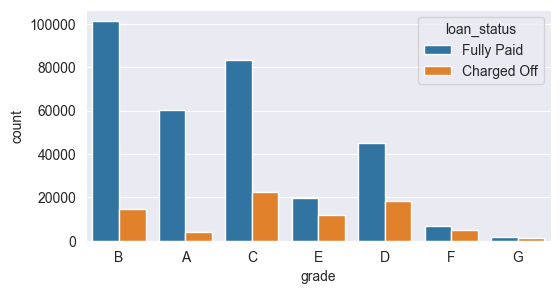

In [21]:
fig=plt.figure(figsize=(6,3))
sns.countplot(x='grade',data=df,hue='loan_status')
plt.show()

### Loan Status Distribution Across Subgrades

C:\Users\CG-DTE\AppData\Local\Temp\ipykernel_9080\3501864292.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sub_grade',data=df,order=order,palette='coolwarm')


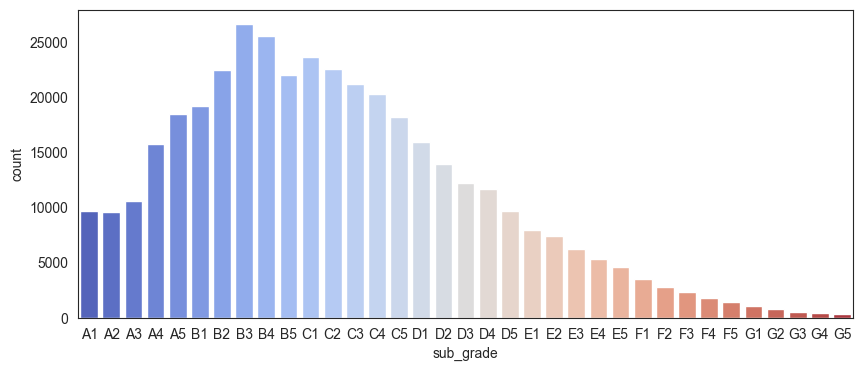

In [23]:
order=df['sub_grade'].value_counts().index.sort_values(ascending=True)
sns.set_style('white')
fig=plt.figure(figsize=(10,4))
sns.countplot(x='sub_grade',data=df,order=order,palette='coolwarm')
plt.show()

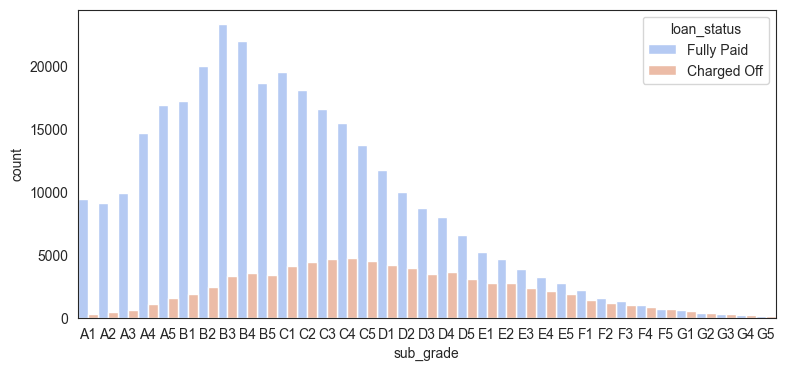

In [24]:

fig=plt.figure(figsize=(9,4))
sns.countplot(x='sub_grade',data=df,order=order,palette='coolwarm',hue='loan_status',width=1)
plt.show()

### High-Risk Borrower Analysis

Subgrades F and G exhibit a higher proportion of charged-off loans and are analyzed separately to better understand borrower risk.

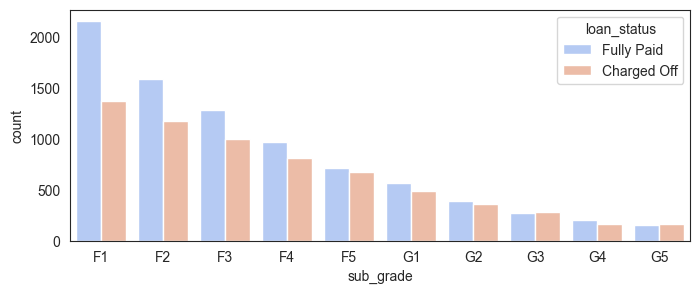

In [25]:

new_df=df[(df['grade']=='F') | (df['grade']=='G')]
ordeR=new_df['sub_grade'].value_counts().index.sort_values(ascending=True)
fig=plt.figure(figsize=(8,3))
sns.countplot(x='sub_grade',data=df,order=ordeR,hue='loan_status',width=0.8,palette='coolwarm')
plt.show()

## Target Variable Encoding

The target variable is converted into a binary format where:

- Fully Paid = 1
- Charged Off = 0

This representation is required for training the neural network classifier.

In [26]:
def Transform(x):
    if x=='Fully Paid':
        return 1
    else:
        return 0
df['loan_repaid']=df['loan_status'].apply(Transform)

In [27]:
df[['loan_repaid','loan_status']]

,loan_repaid,loan_status
0,1,Fully Paid
1,1,Fully Paid
2,1,Fully Paid
3,1,Fully Paid
4,0,Charged Off
...,...,...
396025,1,Fully Paid
396026,1,Fully Paid
396027,1,Fully Paid
396028,1,Fully Paid


### Feature Correlation with Target Variable

To identify the most influential numerical features, the correlation between each feature and the target variable (loan_repaid) is examined.

This helps determine which variables are positively or negatively associated with loan repayment behavior.

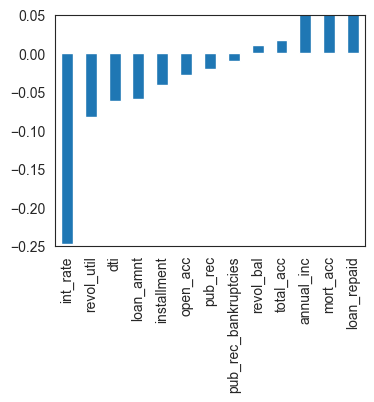

In [28]:

fig=plt.figure(figsize=(4,3))
df.corr(numeric_only=True)['loan_repaid'].sort_values(ascending=True).plot.bar()
plt.ylim(-0.25,0.05)
plt.show()


# Data Preprocessing and Feature Engineering

## Overview

The preprocessing stage focuses on:

- Handling missing values
- Removing redundant features
- Reducing dimensionality
- Converting categorical variables into numerical representations
- Preparing the dataset for neural network training



In [174]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address,loan_repaid
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690",1
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113",1
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113",1
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813",1
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650",0




## Missing Value Analysis

Before model development, missing values are investigated to determine whether features should be retained, imputed, or removed from the dataset.

In [175]:
len(df)

396030

### Missing Value Counts

The total number of missing observations is calculated for each feature.

In [176]:

df.isnull().sum()

loan_amnt                   0
term                        0
int_rate                    0
installment                 0
grade                       0
sub_grade                   0
emp_title               22927
emp_length              18301
home_ownership              0
annual_inc                  0
verification_status         0
issue_d                     0
loan_status                 0
purpose                     0
title                    1756
dti                         0
earliest_cr_line            0
open_acc                    0
pub_rec                     0
revol_bal                   0
revol_util                276
total_acc                   0
initial_list_status         0
application_type            0
mort_acc                37795
pub_rec_bankruptcies      535
address                     0
loan_repaid                 0
dtype: int64

In [177]:
feat_info('emp_title')

The job title supplied by the Borrower when applying for the loan.*


In [178]:
feat_info('emp_length')

Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years. 


In [179]:
feat_info('mort_acc')

Number of mortgage accounts.


### Missing Value Percentage

Missing values are expressed as percentages to better evaluate their impact on model performance.

In [180]:

(df.isnull().sum()/len(df))*100

loan_amnt               0.000000
term                    0.000000
int_rate                0.000000
installment             0.000000
grade                   0.000000
sub_grade               0.000000
emp_title               5.789208
emp_length              4.621115
home_ownership          0.000000
annual_inc              0.000000
verification_status     0.000000
issue_d                 0.000000
loan_status             0.000000
purpose                 0.000000
title                   0.443401
dti                     0.000000
earliest_cr_line        0.000000
open_acc                0.000000
pub_rec                 0.000000
revol_bal               0.000000
revol_util              0.069692
total_acc               0.000000
initial_list_status     0.000000
application_type        0.000000
mort_acc                9.543469
pub_rec_bankruptcies    0.135091
address                 0.000000
loan_repaid             0.000000
dtype: float64

### Employment Information Analysis

The employment-related features are examined to determine whether they provide meaningful predictive value or introduce unnecessary complexity.

In [181]:
feat_info('emp_length')

Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years. 


In [182]:
feat_info('emp_title')

The job title supplied by the Borrower when applying for the loan.*


### Cardinality Analysis of Employment Titles

In [183]:
len(df['emp_title'].unique())

173106

In [184]:
df['emp_title'].value_counts().sort_values(ascending=False)

emp_title
Teacher                     4389
Manager                     4250
Registered Nurse            1856
RN                          1846
Supervisor                  1830
                            ... 
Michael's Arts & Crafts        1
licensed bankere               1
Restor Telecom                 1
Comcast Corporate office       1
analytic33                     1
Name: count, Length: 173105, dtype: int64

### Removing High-Cardinality Features

The emp_title feature contains over 170,000 unique categories, making one-hot encoding impractical.

Therefore, the feature is removed from the dataset.

In [ ]:
df=df.drop('emp_title',axis=1)

### Employment Length Distribution

In [186]:
print(df['emp_length'].dropna().sort_values(ascending=True).unique())

['1 year' '10+ years' '2 years' '3 years' '4 years' '5 years' '6 years'
 '7 years' '8 years' '9 years' '< 1 year']


C:\Users\CG-DTE\AppData\Local\Temp\ipykernel_12368\653318316.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='emp_length',data=df,palette='magma',order=Order)


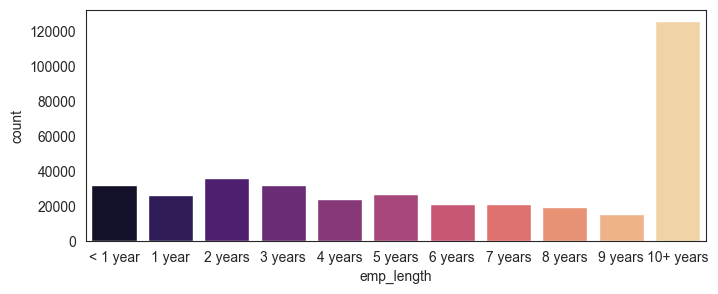

In [187]:
fig=plt.figure(figsize=(8,3))
Order=emp_order = [
    '< 1 year',
    '1 year',
    '2 years',
    '3 years',
    '4 years',
    '5 years',
    '6 years',
    '7 years',
    '8 years',
    '9 years',
    '10+ years'
]
sns.countplot(x='emp_length',data=df,palette='magma',order=Order)
plt.show()

### Employment Length vs Loan Repayment Status

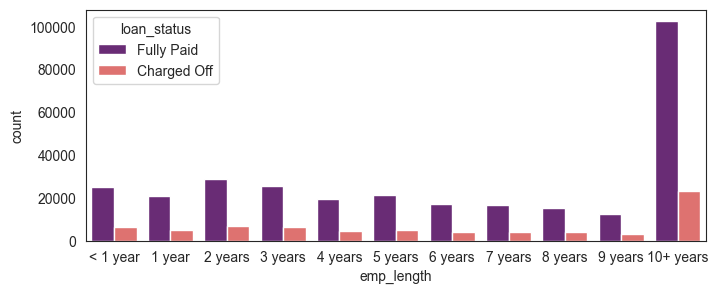

In [188]:
fig=plt.figure(figsize=(8,3))
sns.countplot(x='emp_length',data=df,palette='magma',order=Order,hue='loan_status')
plt.show()

### Charge-Off Rate Analysis

To better understand the relationship between employment length and loan repayment behavior, the charge-off percentage is calculated for each employment category.

This provides a more meaningful comparison than raw counts alone.

In [189]:

default=df[df['loan_status']=='Charged Off'].dropna(subset=['emp_length']).groupby('emp_length')['emp_length'].size()
default

emp_length
1 year        5154
10+ years    23215
2 years       6924
3 years       6182
4 years       4608
5 years       5092
6 years       3943
7 years       4055
8 years       3829
9 years       3070
< 1 year      6563
Name: emp_length, dtype: int64

In [190]:
len(df[df['loan_status']=='Charged Off'])

77673

In [191]:
both=df.dropna(subset=['emp_length']).groupby('emp_length')['emp_length'].size()
both

emp_length
1 year        25882
10+ years    126041
2 years       35827
3 years       31665
4 years       23952
5 years       26495
6 years       20841
7 years       20819
8 years       19168
9 years       15314
< 1 year      31725
Name: emp_length, dtype: int64

In [192]:
df_new = pd.concat([default, both], axis=1)
df_new.columns=['default','overall']

In [193]:
df_new.head()

,default,overall
emp_length,,
1 year,5154,25882
10+ years,23215,126041
2 years,6924,35827
3 years,6182,31665
4 years,4608,23952


In [194]:
df_new['default']/df_new['overall']

emp_length
1 year       0.199135
10+ years    0.184186
2 years      0.193262
3 years      0.195231
4 years      0.192385
5 years      0.192187
6 years      0.189194
7 years      0.194774
8 years      0.199760
9 years      0.200470
< 1 year     0.206872
dtype: float64

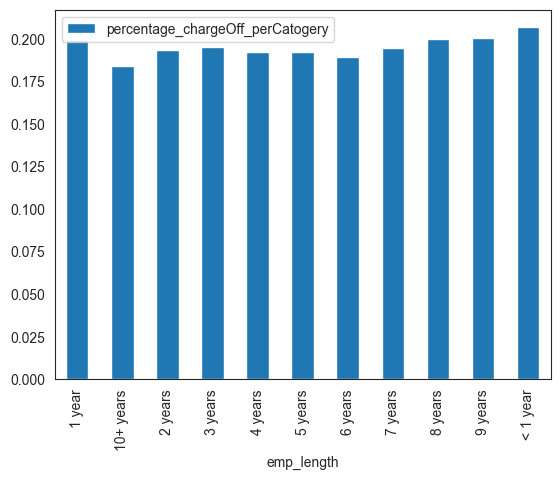

In [195]:
percentage_chargeOff_perCatogery=pd.DataFrame(df_new['default']/df_new['overall'],columns=['percentage_chargeOff_perCatogery'])
percentage_chargeOff_perCatogery.plot.bar()
plt.show()

### Removing Low-Impact Features

The charge-off rate remains relatively consistent across employment categories.

As a result, emp_length is unlikely to contribute significant predictive power and is removed from the dataset.

In [196]:
# so from here we can clearly see that there is no drastic decrease in the percentage_chargeOff of the 10+ year emp_length as compred to other emp_length so we can drop it
# similar to the employment title that has so many catogeries and it was very difficult to create dummy variable from it
df=df.drop('emp_length',axis=1)

In [197]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,verification_status,issue_d,...,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address,loan_repaid
0,10000.0,36 months,11.44,329.48,B,B4,RENT,117000.0,Not Verified,Jan-2015,...,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690",1
1,8000.0,36 months,11.99,265.68,B,B5,MORTGAGE,65000.0,Not Verified,Jan-2015,...,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113",1
2,15600.0,36 months,10.49,506.97,B,B3,RENT,43057.0,Source Verified,Jan-2015,...,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113",1
3,7200.0,36 months,6.49,220.65,A,A2,RENT,54000.0,Not Verified,Nov-2014,...,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813",1
4,24375.0,60 months,17.27,609.33,C,C5,MORTGAGE,55000.0,Verified,Apr-2013,...,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650",0


### Missing Values After Feature Removal

In [198]:
df.isnull().sum()

loan_amnt                   0
term                        0
int_rate                    0
installment                 0
grade                       0
sub_grade                   0
home_ownership              0
annual_inc                  0
verification_status         0
issue_d                     0
loan_status                 0
purpose                     0
title                    1756
dti                         0
earliest_cr_line            0
open_acc                    0
pub_rec                     0
revol_bal                   0
revol_util                276
total_acc                   0
initial_list_status         0
application_type            0
mort_acc                37795
pub_rec_bankruptcies      535
address                     0
loan_repaid                 0
dtype: int64

### Redundant Feature Analysis

The title feature appears to be a textual variation of the loan purpose category.

A comparison is performed to determine whether both features provide unique information.

In [199]:
df['purpose'].head(10)

0              vacation
1    debt_consolidation
2           credit_card
3           credit_card
4           credit_card
5    debt_consolidation
6      home_improvement
7           credit_card
8    debt_consolidation
9    debt_consolidation
Name: purpose, dtype: object

In [200]:
df['title'].head(10)

0                   Vacation
1         Debt consolidation
2    Credit card refinancing
3    Credit card refinancing
4      Credit Card Refinance
5         Debt consolidation
6           Home improvement
7       No More Credit Cards
8         Debt consolidation
9         Debt Consolidation
Name: title, dtype: object

### Removing Redundant Features

The title attribute contains information that largely overlaps with the purpose feature.

To reduce redundancy and dimensionality, the title column is removed.

In [201]:
df=df.drop('title',axis=1)

In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   home_ownership        396030 non-null  object 
 7   annual_inc            396030 non-null  float64
 8   verification_status   396030 non-null  object 
 9   issue_d               396030 non-null  object 
 10  loan_status           396030 non-null  object 
 11  purpose               396030 non-null  object 
 12  dti                   396030 non-null  float64
 13  earliest_cr_line      396030 non-null  object 
 14  open_acc              396030 non-null  float64
 15  

---
## Handling Missing Mortgage Account Information

The mort_acc feature contains a substantial number of missing values.

Rather than dropping the feature, relationships with other variables are explored to develop an informed imputation strategy.


---
### Understanding the mort_acc Feature

In [203]:
feat_info('mort_acc')

Number of mortgage accounts.


### Distribution of Mortgage Accounts

In [204]:
df['mort_acc'].value_counts()

mort_acc
0.0     139777
1.0      60416
2.0      49948
3.0      38049
4.0      27887
5.0      18194
6.0      11069
7.0       6052
8.0       3121
9.0       1656
10.0       865
11.0       479
12.0       264
13.0       146
14.0       107
15.0        61
16.0        37
17.0        22
18.0        18
19.0        15
20.0        13
24.0        10
22.0         7
21.0         4
25.0         4
27.0         3
26.0         2
32.0         2
31.0         2
23.0         2
34.0         1
28.0         1
30.0         1
Name: count, dtype: int64

In [205]:
# The number of missing values in the mort_acc column
df['mort_acc'].isnull().sum()

np.int64(37795)

### Correlation-Based Imputation Strategy

Several approaches can be used to handle missing mortgage account values.

To identify the most suitable method, correlations between mort_acc and other numerical features are examined.

In [206]:
df.corr(numeric_only=True)['mort_acc'].sort_values(ascending=False)

mort_acc                1.000000
total_acc               0.381072
annual_inc              0.236320
loan_amnt               0.222315
revol_bal               0.194925
installment             0.193694
open_acc                0.109205
loan_repaid             0.073111
pub_rec_bankruptcies    0.027239
pub_rec                 0.011552
revol_util              0.007514
dti                    -0.025439
int_rate               -0.082583
Name: mort_acc, dtype: float64

In [207]:
df[['total_acc','mort_acc']]['total_acc'].sort_values(ascending=False)

105682    151.0
123703    150.0
53317     135.0
82628     129.0
96571     124.0
          ...  
241653      2.0
188372      2.0
3767        2.0
135808      2.0
242957      2.0
Name: total_acc, Length: 396030, dtype: float64

### Relationship Between Total Accounts and Mortgage Accounts

The total_acc feature shows the strongest relationship with mort_acc.

This relationship is used to estimate missing mortgage account values.

In [208]:
df.groupby('total_acc')['mort_acc'].mean().loc[19]

np.float64(1.3580128970623357)

### Imputing Missing Mortgage Account Values

Missing mortgage account values are replaced using the average mort_acc value corresponding to each total_acc category.

In [209]:
new=df.groupby('total_acc')['mort_acc'].mean()

def fill_missing_values(col):
    mort_a=col['mort_acc']
    total_a=col['total_acc']
    if pd.isnull(mort_a):
        return new.loc[total_a]
    else:
        return mort_a

In [210]:
df['mort_acc']=df[['total_acc','mort_acc']].apply(fill_missing_values,axis=1)

In [211]:
print(df['mort_acc'].isnull().sum())

0


In [212]:
df.isnull().sum()

loan_amnt                 0
term                      0
int_rate                  0
installment               0
grade                     0
sub_grade                 0
home_ownership            0
annual_inc                0
verification_status       0
issue_d                   0
loan_status               0
purpose                   0
dti                       0
earliest_cr_line          0
open_acc                  0
pub_rec                   0
revol_bal                 0
revol_util              276
total_acc                 0
initial_list_status       0
application_type          0
mort_acc                  0
pub_rec_bankruptcies    535
address                   0
loan_repaid               0
dtype: int64

### Final Missing Value Treatment

The remaining missing observations account for less than 0.5% of the dataset.

These records are removed to ensure a fully complete dataset for modeling.

In [213]:
df=df.dropna(subset=['revol_util','pub_rec_bankruptcies'])

In [214]:
df.isnull().sum()

loan_amnt               0
term                    0
int_rate                0
installment             0
grade                   0
sub_grade               0
home_ownership          0
annual_inc              0
verification_status     0
issue_d                 0
loan_status             0
purpose                 0
dti                     0
earliest_cr_line        0
open_acc                0
pub_rec                 0
revol_bal               0
revol_util              0
total_acc               0
initial_list_status     0
application_type        0
mort_acc                0
pub_rec_bankruptcies    0
address                 0
loan_repaid             0
dtype: int64

# Categorical Encoding and Feature Transformation
After handling missing values, the remaining categorical features must be converted into numerical representations before they can be used by the neural network.

## Loan Term Transformation

The loan duration feature is converted from a string representation into a numerical feature containing the loan period in months.

In [215]:
df.select_dtypes(exclude=['number']).columns

Index(['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status',
       'issue_d', 'loan_status', 'purpose', 'earliest_cr_line',
       'initial_list_status', 'application_type', 'address'],
      dtype='object')














### Encoding Subgrade Categories
The identified categorical features are processed individually using appropriate encoding and transformation techniques.
The sub_grade feature is transformed using one-hot encoding to convert categorical values into machine-learning compatible numerical features.

In [216]:
df['term'] = df['term'].map(lambda x: int(x.split()[0]))

In [217]:
df['term'].value_counts()

term
36    301247
60     93972
Name: count, dtype: int64

### grade feature

**We already know grade is part of sub_grade, so just drop the grade feature.**

In [218]:
df=df.drop('grade',axis=1)

In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 395219 entries, 0 to 396029
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             395219 non-null  float64
 1   term                  395219 non-null  int64  
 2   int_rate              395219 non-null  float64
 3   installment           395219 non-null  float64
 4   sub_grade             395219 non-null  object 
 5   home_ownership        395219 non-null  object 
 6   annual_inc            395219 non-null  float64
 7   verification_status   395219 non-null  object 
 8   issue_d               395219 non-null  object 
 9   loan_status           395219 non-null  object 
 10  purpose               395219 non-null  object 
 11  dti                   395219 non-null  float64
 12  earliest_cr_line      395219 non-null  object 
 13  open_acc              395219 non-null  float64
 14  pub_rec               395219 non-null  float64
 15  revol

### Encoding Subgrade Categories

The sub_grade feature is transformed using one-hot encoding to convert categorical values into machine-learning compatible numerical features.

In [220]:
df=pd.get_dummies(df,columns=['sub_grade'],drop_first=True,dtype=int)

In [221]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'home_ownership',
       'annual_inc', 'verification_status', 'issue_d', 'loan_status',
       'purpose', 'dti', 'earliest_cr_line', 'open_acc', 'pub_rec',
       'revol_bal', 'revol_util', 'total_acc', 'initial_list_status',
       'application_type', 'mort_acc', 'pub_rec_bankruptcies', 'address',
       'loan_repaid', 'sub_grade_A2', 'sub_grade_A3', 'sub_grade_A4',
       'sub_grade_A5', 'sub_grade_B1', 'sub_grade_B2', 'sub_grade_B3',
       'sub_grade_B4', 'sub_grade_B5', 'sub_grade_C1', 'sub_grade_C2',
       'sub_grade_C3', 'sub_grade_C4', 'sub_grade_C5', 'sub_grade_D1',
       'sub_grade_D2', 'sub_grade_D3', 'sub_grade_D4', 'sub_grade_D5',
       'sub_grade_E1', 'sub_grade_E2', 'sub_grade_E3', 'sub_grade_E4',
       'sub_grade_E5', 'sub_grade_F1', 'sub_grade_F2', 'sub_grade_F3',
       'sub_grade_F4', 'sub_grade_F5', 'sub_grade_G1', 'sub_grade_G2',
       'sub_grade_G3', 'sub_grade_G4', 'sub_grade_G5'],
      dtype='object')

In [222]:
df.select_dtypes(exclude=['number']).columns 

Index(['home_ownership', 'verification_status', 'issue_d', 'loan_status',
       'purpose', 'earliest_cr_line', 'initial_list_status',
       'application_type', 'address'],
      dtype='object')

## Encoding Additional Categorical Features


In [223]:
df=pd.get_dummies(df,columns=['verification_status','application_type','initial_list_status'],drop_first=True,dtype=int)

In [224]:
df.select_dtypes(exclude=['number']).columns 

Index(['home_ownership', 'issue_d', 'loan_status', 'purpose',
       'earliest_cr_line', 'address'],
      dtype='object')

## Home Ownership Feature Engineering
The distribution of home ownership categories is examined prior to encoding.

In [225]:
df['home_ownership'].value_counts()

home_ownership
MORTGAGE    198022
RENT        159395
OWN          37660
OTHER          110
NONE            29
ANY              3
Name: count, dtype: int64

In [226]:
def Replace(x):
    if (x=='NONE')| (x=='ANY'):
        return 'OTHER'
    else:
        return x
df['home_ownership']=df['home_ownership'].apply(Replace)

In [227]:
df['home_ownership'].value_counts()

home_ownership
MORTGAGE    198022
RENT        159395
OWN          37660
OTHER          142
Name: count, dtype: int64

**Now we will Convert these to dummy variables, but we will replace NONE and ANY with OTHER, so that we end up with just 4 categories, MORTGAGE, RENT, OWN, OTHER. Then concatenate them with the original dataframe. Remember to set drop_first=True and to drop the original columns.**

In [228]:
df=pd.get_dummies(df,columns=['home_ownership'],drop_first=True,dtype=int)

In [229]:
df.select_dtypes(exclude=['number']).columns 

Index(['issue_d', 'loan_status', 'purpose', 'earliest_cr_line', 'address'], dtype='object')

In [ ]:
## Geographic Feature Engineering
**TASK: Let's feature engineer a zip code column from the address in the data set. Create a column called 'zip_code' that extracts the zip code from the address column.**

In [230]:
df['address'] = df['address'].map(lambda x: x.split()[-1])

In [231]:
df['address'].head()

0    22690
1    05113
2    05113
3    00813
4    11650
Name: address, dtype: object

**Now we will make this zip_code column into dummy variables using pandas. Concatenate the result and drop the original zip_code column along with dropping the address column.**

In [232]:
df=pd.get_dummies(df,columns=['address'],drop_first=True,dtype=int)

In [233]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 395219 entries, 0 to 396029
Data columns (total 69 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   loan_amnt                            395219 non-null  float64
 1   term                                 395219 non-null  int64  
 2   int_rate                             395219 non-null  float64
 3   installment                          395219 non-null  float64
 4   annual_inc                           395219 non-null  float64
 5   issue_d                              395219 non-null  object 
 6   loan_status                          395219 non-null  object 
 7   purpose                              395219 non-null  object 
 8   dti                                  395219 non-null  float64
 9   earliest_cr_line                     395219 non-null  object 
 10  open_acc                             395219 non-null  float64
 11  pub_rec           

## Data Leakage Prevention
**This would be data leakage, we wouldn't know beforehand whether or not a loan would be issued when using our model, so in theory we wouldn't have an issue_date, drop this feature.**

In [234]:
df=df.drop('issue_d',axis=1)

In [235]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 395219 entries, 0 to 396029
Data columns (total 68 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   loan_amnt                            395219 non-null  float64
 1   term                                 395219 non-null  int64  
 2   int_rate                             395219 non-null  float64
 3   installment                          395219 non-null  float64
 4   annual_inc                           395219 non-null  float64
 5   loan_status                          395219 non-null  object 
 6   purpose                              395219 non-null  object 
 7   dti                                  395219 non-null  float64
 8   earliest_cr_line                     395219 non-null  object 
 9   open_acc                             395219 non-null  float64
 10  pub_rec                              395219 non-null  float64
 11  revol_bal         

## Credit History Feature Engineering
**This appears to be a historical time stamp feature.we will Extract the year from this feature using a .apply function, then convert it to a numeric feature. Set this new data to a feature column called 'earliest_cr_year'.Then drop the earliest_cr_line feature.**

In [236]:
df['earliest_cr_year']=df['earliest_cr_line'].apply(lambda x: int(x.split('-')[-1]))

In [237]:
df=df.drop('earliest_cr_line',axis=1)

In [238]:
df['purpose'].value_counts()

purpose
debt_consolidation    234169
credit_card            82923
home_improvement       23961
other                  21059
major_purchase          8756
small_business          5656
car                     4670
medical                 4175
moving                  2842
vacation                2442
house                   2197
wedding                 1794
renewable_energy         329
educational              246
Name: count, dtype: int64

## Train Test Split

**TASK: Import train_test_split from sklearn.**

In [239]:
from sklearn.model_selection import train_test_split

**we will drop the load_status column we created earlier, since its a duplicate of the loan_repaid column. We'll use the loan_repaid column since its already in 0s and 1s.**

In [240]:
df=df.drop(['loan_status'],axis=1)

In [241]:
df=pd.get_dummies(df,columns=['purpose'],dtype=int)

In [242]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 395219 entries, 0 to 396029
Data columns (total 80 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   loan_amnt                            395219 non-null  float64
 1   term                                 395219 non-null  int64  
 2   int_rate                             395219 non-null  float64
 3   installment                          395219 non-null  float64
 4   annual_inc                           395219 non-null  float64
 5   dti                                  395219 non-null  float64
 6   open_acc                             395219 non-null  float64
 7   pub_rec                              395219 non-null  float64
 8   revol_bal                            395219 non-null  float64
 9   revol_util                           395219 non-null  float64
 10  total_acc                            395219 non-null  float64
 11  mort_acc          

**TASK: Set X and y variables to the .values of the features and label.**

In [243]:
#df = df.sample(frac=0.1,random_state=101)
x=df.drop('loan_repaid',axis=1).values
y=df['loan_repaid'].values




## Grabbing a Sample for Training Time



In [244]:
#df = df.sample(frac=0.1,random_state=101)
print(len(df))

395219


**.We will Perform a train/test split with test_size=0.2 and a random_state of 101.**

In [245]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=101,test_size=0.2)

## Normalizing the Data

**We will Use a MinMaxScaler to normalize the feature data X_train and X_test. As we don't want data leakge from the test set so we only fit on the X_train data.**

In [247]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [248]:
x_train_s=scaler.fit_transform(x_train)
x_test_s=scaler.transform(x_test)

# Creating the Model



In [249]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

In [250]:
model = Sequential()
# Choose whatever number of layers/neurons you want.
model.add(Dense(79,'relu'))
model.add(Dropout(0.3))

model.add(Dense(39,'relu'))
model.add(Dropout(0.3))

model.add(Dense(19,'relu'))
model.add(Dropout(0.3))
#https://stats.stackexchange.com/questions/181/how-to-choose-the-number-of-hidden-layers-and-nodes-in-a-feedforward-neural-netw

model.add(Dense(1,'sigmoid'))
model.compile(optimizer='adam',loss='binary_crossentropy')
# Remember to compile()

In [251]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop=EarlyStopping(monitor='val_loss',mode='min',patience=10)

In [252]:

model.fit(x_train_s,y_train,batch_size=256,validation_data=(x_test_s,y_test),callbacks=[early_stop],epochs=1000)

Epoch 1/1000
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 197s 21ms/step - loss: 0.3095 - val_loss: 0.2657
Epoch 2/1000
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - loss: 0.2672 - val_loss: 0.2637
Epoch 3/1000
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 33s 13ms/step - loss: 0.2642 - val_loss: 0.2630
Epoch 4/1000
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 0.2629 - val_loss: 0.2620
Epoch 5/1000
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 0.2621 - val_loss: 0.2625
Epoch 6/1000
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.2616 - val_loss: 0.2621
Epoch 7/1000
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.2608 - val_loss: 0.2619
Epoch 8/1000
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.2607 - val_loss: 0.2617
Epoch 9/1000
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.2603 - val_loss: 0.2628
Epoch 10/1000
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.2602 - val_loss: 0.2624
Epoch 11/1000
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.2597 - val_los

**Now we will Save our model.**

In [254]:
from tensorflow.keras.models import load_model

In [255]:
model.save('classification_model.keras')

In [256]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 79)                  │           6,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 79)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 39)                  │           3,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 39)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 19)                  │             760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 19)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              20 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,662 (119.78 KB)

 Trainable params: 10,220 (39.92 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,442 (79.86 KB)

# Evaluating Model Performance.

**We will aslo Plot out the validation loss versus the training loss.**

In [258]:
losses=pd.DataFrame(model.history.history)

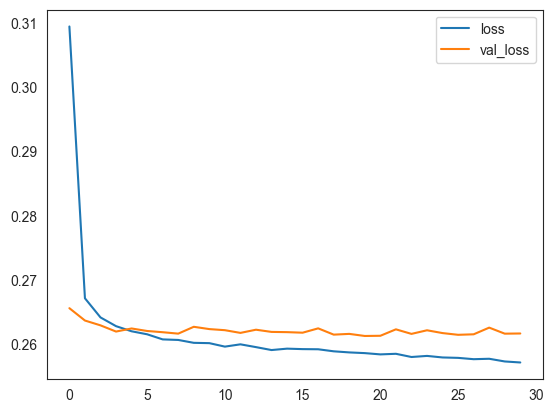

In [259]:
losses.plot.line()
sns.set_style('darkgrid')
plt.show()

**TASK: Create predictions from the X_test set and display a classification report and confusion matrix for the X_test set.**

In [260]:

model_predict=model.predict(x_test_s)
predict=(model_predict>0.5).astype(int)

2471/2471 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step 


In [261]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [262]:
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       1.00      0.43      0.60     15658
           1       0.88      1.00      0.93     63386

    accuracy                           0.89     79044
   macro avg       0.94      0.71      0.77     79044
weighted avg       0.90      0.89      0.87     79044



In [263]:
print(confusion_matrix(y_test,predict))

[[ 6728  8930]
 [    3 63383]]


In [264]:
x_train_s.shape

(316175, 79)

**We have a customer given below, would you offer this person a loan?.**

In [265]:
import random
random.seed(101)
random_ind = random.randint(0,len(df))

new_customer = df.drop('loan_repaid',axis=1).iloc[random_ind]
new_customer

loan_amnt                   25000.00
term                           60.00
int_rate                       18.24
installment                   638.11
annual_inc                  61665.00
                              ...   
purpose_other                   0.00
purpose_renewable_energy        0.00
purpose_small_business          0.00
purpose_vacation                0.00
purpose_wedding                 0.00
Name: 305323, Length: 79, dtype: float64

In [266]:
new_customer=pd.DataFrame(new_customer)
scaled_customer=scaler.transform(new_customer.transpose().values)

In [267]:
(model.predict(scaled_customer)>0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step


array([[1]])

**Now let's check, did this person actually end up paying back their loan?**

In [268]:
print((model.predict(scaled_customer)>0.5).astype(int).reshape(1,)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1


###### Yes the loan was Repaid!!!!